<h1>LoanDataAnalysis</h1>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [4]:
df = pd.read_csv("../data/Loan_default.csv")
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


1. Number of Rows

In [5]:
print(f"Number of rows : {df.shape[0]}")

Number of rows : 255347


2. Number of columns

In [ ]:
print(f"Number of columns : {df.shape[1]}")

Number of columns : 18


In [7]:
print(df.columns)

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')


4. Statistical Values

In [8]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


5. Dataset info

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

6. Number of null values for each column in the dataset

In [10]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

7. Number of null values thoughout the dataset

In [11]:
print(f'Null values thoughout the dataset : {df.isnull().sum().sum()}')

Null values thoughout the dataset : 0


8. All the type of employment

In [12]:
df['EmploymentType'].unique()

array(['Full-time', 'Unemployed', 'Self-employed', 'Part-time'],
      dtype=object)

9. All type of education

In [13]:
df['Education'].unique()

array(["Bachelor's", "Master's", 'High School', 'PhD'], dtype=object)

10. Credit-Score distribution of dataset

Text(0, 0.5, 'Frequency')

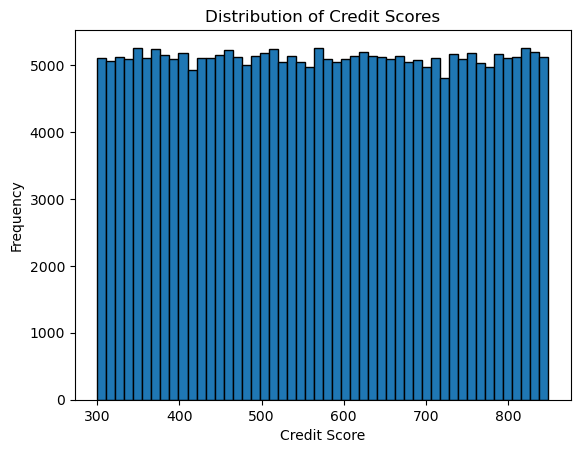

In [14]:
plt.hist(df['CreditScore'],bins=50,edgecolor='black')

plt.title("Distribution of Credit Scores")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")

11. Loan Defaulted vs non-defaulted

Text(0, 0.5, 'Number of Records')

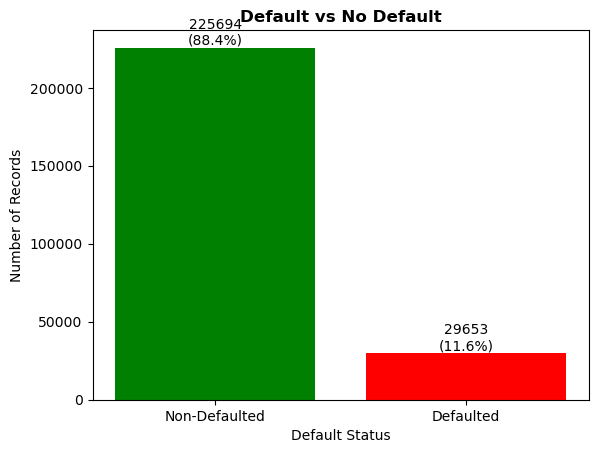

In [15]:
Counts = df['Default'].value_counts()
total = df['Default'].count()

labels = ['Non-Defaulted','Defaulted']

bars = plt.bar(labels, Counts.values, color=['g','r'])

for bar in bars:
    height = bar.get_height()
    percentage = height / total * 100

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height}\n({percentage:.1f}%)',
        ha='center',
        va='bottom'
    )

plt.title('Default vs No Default', fontweight='bold')
plt.xlabel("Default Status")
plt.ylabel("Number of Records")




12. Education-type wise Income, LoanAmount, CreditScore

In [16]:
df.groupby('Education')[['Income','LoanAmount','CreditScore']].aggregate(['min','max','mean'])

Income                       LoanAmount                         \
               min     max          mean        min     max           mean   
Education                                                                    
Bachelor's   15004  149999  82580.142622       5001  249997  127390.632026   
High School  15000  149999  82294.182949       5015  249999  127393.676823   
Master's     15000  149995  82835.208936       5000  249990  127710.986450   
PhD          15000  149997  82287.789587       5017  249998  127823.681178   

            CreditScore                   
                    min  max        mean  
Education                                 
Bachelor's          300  849  574.094227  
High School         300  849  574.812419  
Master's            300  849  573.525802  
PhD                 300  849  574.624046

13. Employment-type wise Income, LoanAmount, CreditScore

In [17]:
df.groupby('EmploymentType')[['Income','LoanAmount','CreditScore']].aggregate(['min','max','mean'])

Income                       LoanAmount                         \
                  min     max          mean        min     max           mean   
EmploymentType                                                                  
Full-time       15000  149994  82890.297961       5005  249999  127469.866595   
Part-time       15000  149999  82389.357367       5001  249969  127329.702904   
Self-employed   15002  149997  82446.709038       5000  249993  127436.700232   
Unemployed      15000  149997  82272.366508       5009  249990  128079.958182   

               CreditScore                   
                       min  max        mean  
EmploymentType                               
Full-time              300  849  573.407393  
Part-time              300  849  574.095525  
Self-employed          300  849  574.680046  
Unemployed             300  849  574.873825

14. LoanPurpose-type wise Income, LoanAmount, CreditScore 

In [18]:
df.groupby('LoanPurpose')[['Income','LoanAmount','CreditScore']].aggregate(['min','max','mean'])

Income                       LoanAmount                         \
               min     max          mean        min     max           mean   
LoanPurpose                                                                  
Auto         15016  149996  82508.299504       5020  249988  127857.908721   
Business     15000  149999  82897.470798       5012  249999  127141.807458   
Education    15000  149996  82217.746064       5001  249998  127645.822841   
Home         15002  149995  82402.193523       5000  249996  127622.382853   
Other        15000  149999  82469.035216       5012  249997  127629.648054   

            CreditScore                   
                    min  max        mean  
LoanPurpose                               
Auto                300  849  574.575918  
Business            300  849  574.062108  
Education           300  849  573.212842  
Home                300  849  575.061011  
Other               300  849  574.407864

15. Number of Duplicated Records

In [19]:
print(f"Number of duplicated records : {df.duplicated(subset=['Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default']).sum()}")

Number of duplicated records : 0


16. Which numerical features contain outliers?

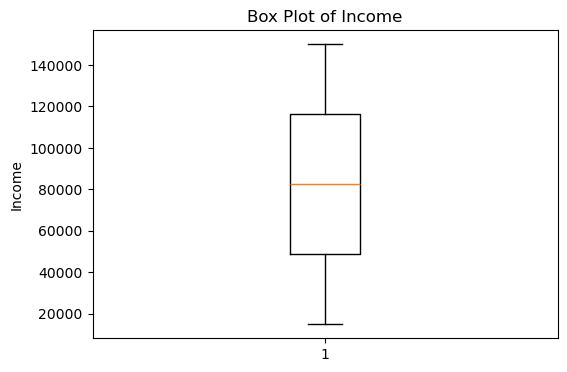

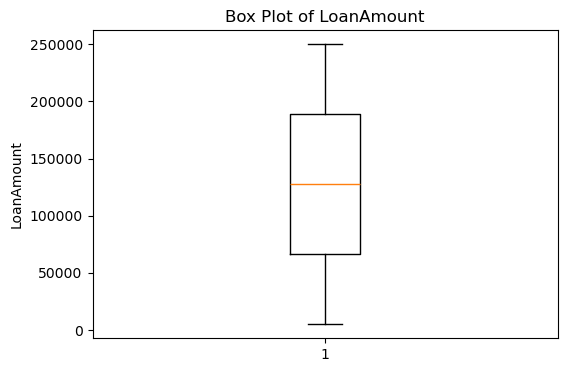

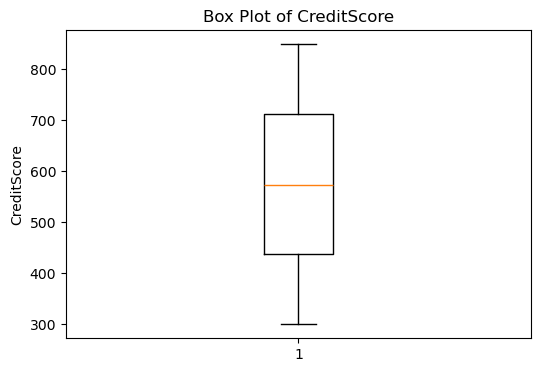

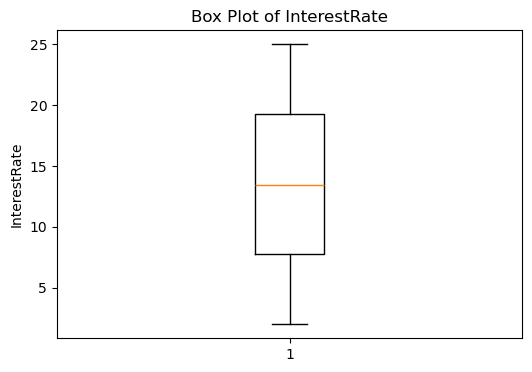

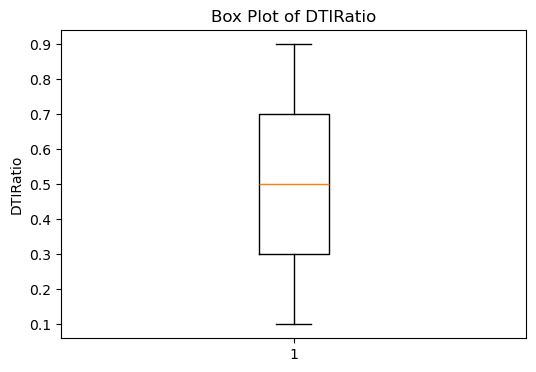

In [20]:
columns = ['Income', 'LoanAmount', 'CreditScore', 'InterestRate', 'DTIRatio']

for column in columns:
    plt.figure(figsize=(6,4))

    plt.boxplot(df[column])

    plt.title(f'Box Plot of {column}')
    plt.ylabel(column)

    plt.show()

17. Do defaulted borrowers have different loan amounts?

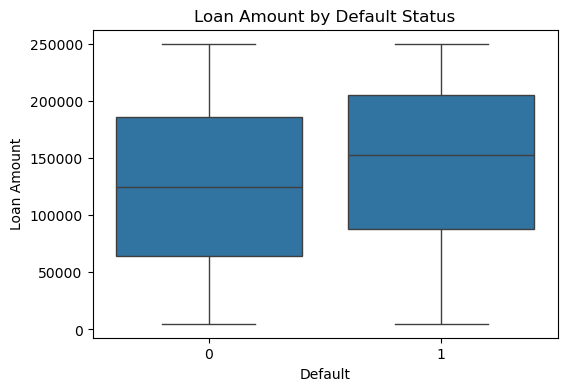

In [21]:
plt.figure(figsize=(6,4))

sns.boxplot(x='Default', y='LoanAmount', data=df)

plt.title("Loan Amount by Default Status")
plt.xlabel("Default")
plt.ylabel("Loan Amount")

plt.show()

18. Do defaulted borrowers have different credit scores?

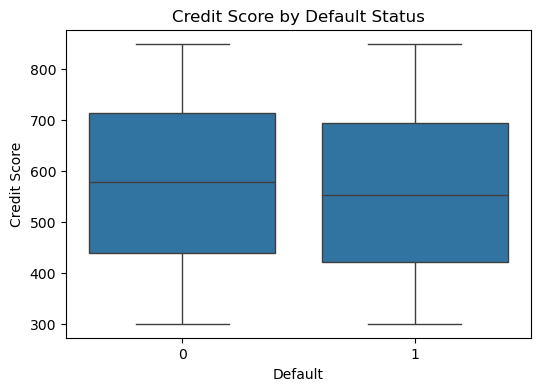

In [22]:
plt.figure(figsize=(6,4))

sns.boxplot(x='Default', y='CreditScore', data=df)

plt.title("Credit Score by Default Status")
plt.xlabel("Default")
plt.ylabel("Credit Score")

plt.show()

19. Is there a relationship between Income and Loan Amount?

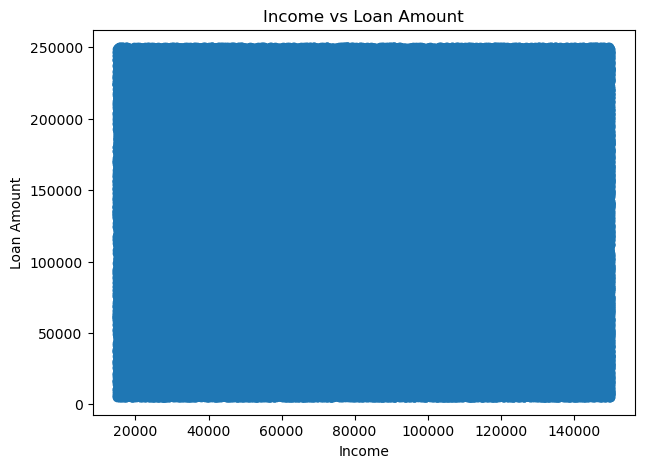

In [23]:
plt.figure(figsize=(7,5))

plt.scatter(df['Income'], df['LoanAmount'])

plt.title("Income vs Loan Amount")
plt.xlabel("Income")
plt.ylabel("Loan Amount")

plt.show()

20. Which feature is most strongly correlated with the others?

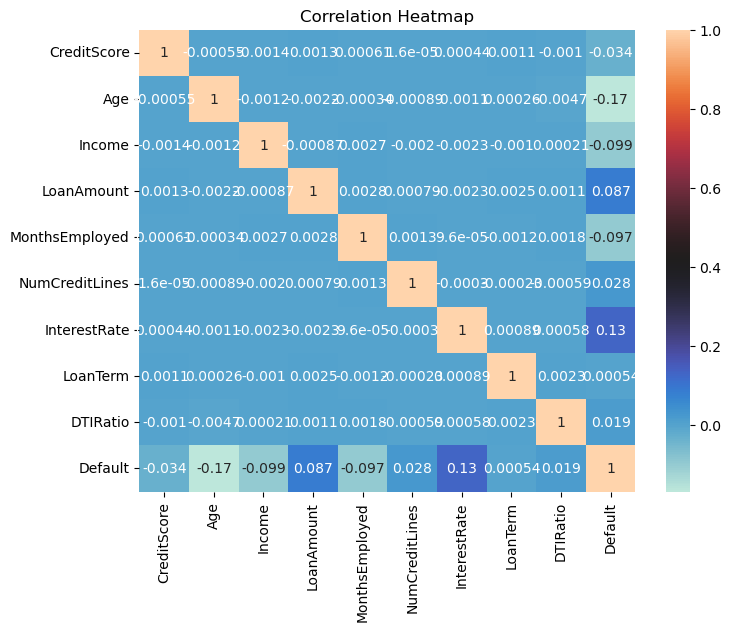

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['CreditScore',
        'Age',
        'Income',
        'LoanAmount',
        'MonthsEmployed',
        'NumCreditLines',
        'InterestRate',
        'LoanTerm',
        'DTIRatio',
        'Default']].corr(),
    annot=True,
    cmap='icefire'
)

plt.title("Correlation Heatmap")

plt.show()